In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/retail_sales_rawdataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# Retail Sales Performance Analysis

## Data Cleaning & Data Understanding

This notebook performs initial data inspection and cleaning before analysis

In [19]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 9)


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [21]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [22]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='str')

## Convert Date Column

The 'date' column is currently stored as text ('object'). It is converted to date time format to enable time-based analysis such as monthly and quarterly sales trends.

In [27]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[us]
 2   customer_id       1000 non-null   str           
 3   gender            1000 non-null   str           
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   str           
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


## Validate Total Amount

To ensure data quality, verify that the total amount equals quantity multiplied by price per unit.

In [28]:
df["calculated_total"] = df["quantity"] * df["price_per_unit"]

df[df["calculated_total"] != df["total_amount"]]

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,calculated_total


In [29]:
df.drop(columns="calculated_total", inplace=True)

df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [30]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["month_name"] = df["date"].dt.month_name()

df["quarter"] = df["date"].dt.quarter

df["day_of_week"] = df["date"].dt.day_name()

df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,month_name,quarter,day_of_week
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,4,Friday
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,1,Monday
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,1,Friday
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,2,Sunday
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,2,Saturday


## Exploratory Data Analysis (EDA)

This section explores sales trends, customer demographics and product performance using descriptive statistics and visualisations.

In [32]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [41]:
sales_category = (
    df.groupby("product_category")["total_amount"]
      .sum()
      .sort_values(ascending=False)
)

sales_category

product_category
Electronics    156905
Clothing       155580
Beauty         143515
Name: total_amount, dtype: int64

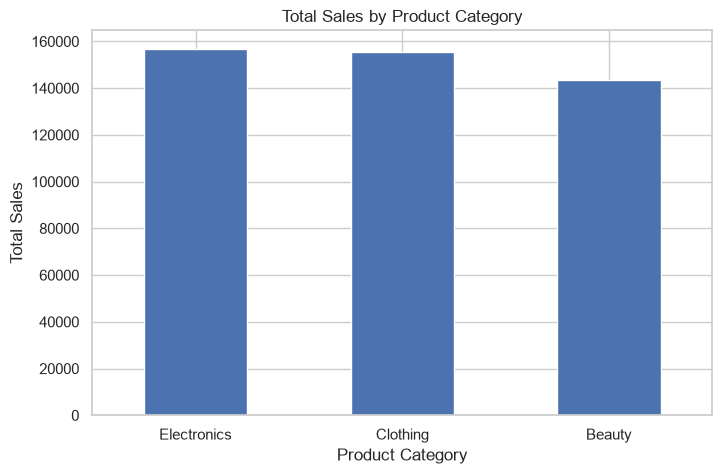

In [42]:
sales_category.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

## Monthly Sales Trend

Analyse monthly sales performance to identify seasonal patterns and revenue trends.

In [44]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("month_name")["total_amount"]
      .sum()
      .reindex(month_order)
)

monthly_sales

month_name
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: total_amount, dtype: int64

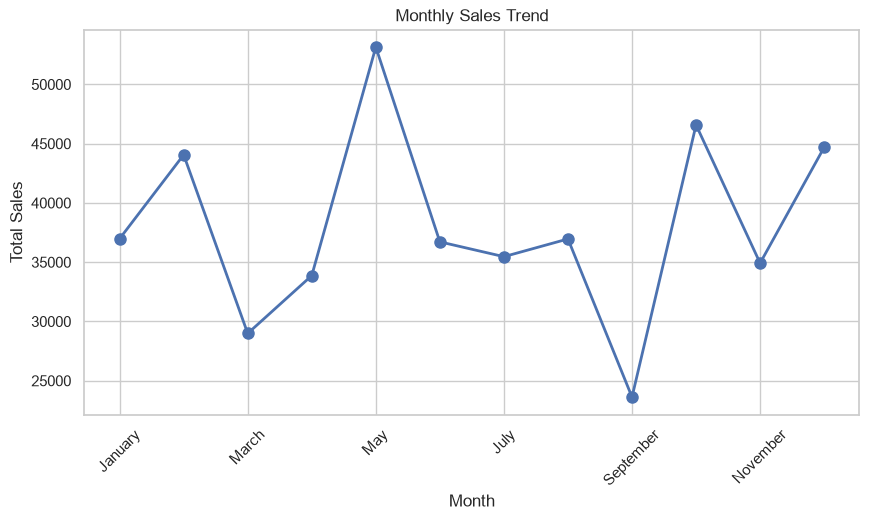

In [62]:
monthly_sales.plot(
    kind="line",
    marker="o",
    markersize=8,
    linewidth=2,
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Insight

Sales varied across the year, indicating fluctuations in customer purchasing behaviour.

May recorded the highest total sales, while September had the lowest sales performance.

These results suggest that customer demand changes over time and may be influenced by seasonal or promotional factors.

## Sales by Gender

Compare total sales generated by male and female customers.

In [66]:
sales_gender = (
    df.groupby("gender")["total_amount"]
      .sum()
)

sales_gender

gender
Female    232840
Male      223160
Name: total_amount, dtype: int64

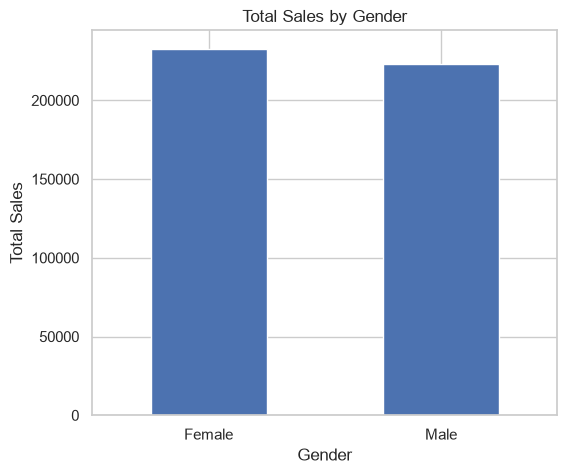

In [67]:
sales_gender.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

### Insight

Female customers generated slightly higher total sales than male customers.

The difference in revenue is relatively small, suggesting that both genders contributed almost equally to the business's overall sales.

## Customer Age Distribution

Analyse the age distribution of customers to better understand the customer base.

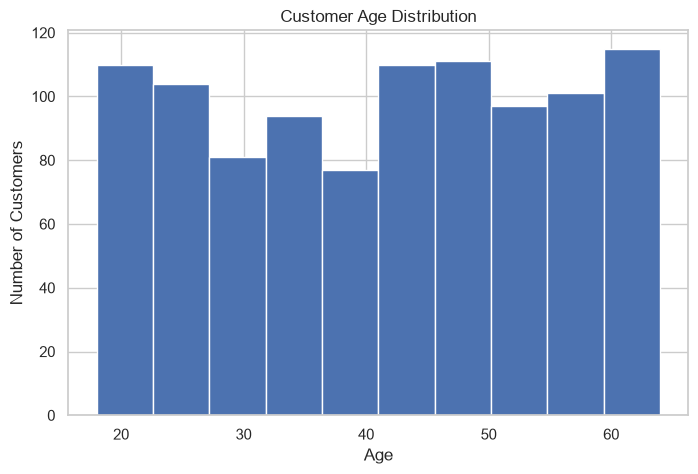

In [68]:
plt.figure(figsize=(8,5))

plt.hist(
    df["age"],
    bins=10
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

### Insight

Customers are distributed across a wide range of ages, indicating that the business serves multiple age groups.

Further analysis could identify which age segments contribute the highest revenue.›

## Correlation Analysis

Examine the relationships between numerical variables using a correlation matrix.

In [69]:
correlation = df[
    ["age", "quantity", "price_per_unit", "total_amount"]
].corr()

correlation

,age,quantity,price_per_unit,total_amount
age,1.000000,-0.023737,-0.038423,-0.060568
quantity,-0.023737,1.000000,0.017501,0.373707
price_per_unit,-0.038423,0.017501,1.000000,0.851925
total_amount,-0.060568,0.373707,0.851925,1.000000


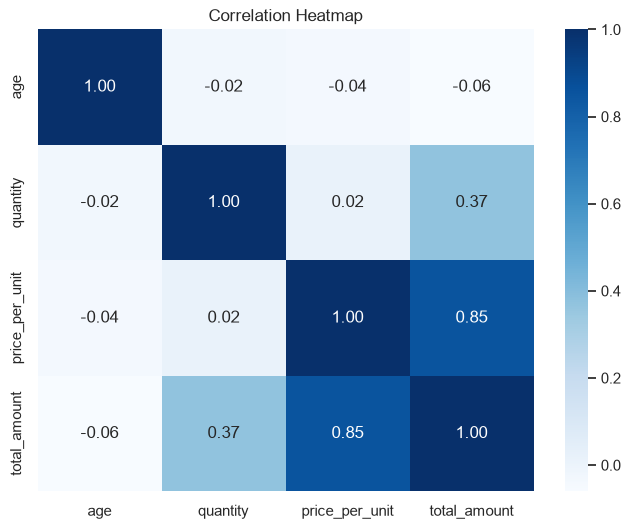

In [70]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The heatmap shows the strength of relationships between numerical variables.

Total sales are expected to have a stronger relationship with quantity and price per unit than with customer age.

Age appears to have little or no correlation with purchasing value.

## Top 10 Highest Sales Transactions

Identify the transactions with the highest sales value.

In [71]:
top_sales = (
    df.sort_values(
        by="total_amount",
        ascending=False
    )
    .head(10)
)

top_sales

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,month_name,quarter,day_of_week
571,572,2023-04-20,CUST572,Male,31,Clothing,4,500,2000,2023,4,April,2,Thursday
88,89,2023-10-01,CUST089,Female,55,Electronics,4,500,2000,2023,10,October,4,Sunday
502,503,2023-10-25,CUST503,Male,45,Beauty,4,500,2000,2023,10,October,4,Wednesday
560,561,2023-05-27,CUST561,Female,64,Clothing,4,500,2000,2023,5,May,2,Saturday
831,832,2023-09-11,CUST832,Male,47,Beauty,4,500,2000,2023,9,September,3,Monday
807,808,2023-04-01,CUST808,Male,33,Beauty,4,500,2000,2023,4,April,2,Saturday
576,577,2023-02-13,CUST577,Male,21,Beauty,4,500,2000,2023,2,February,1,Monday
945,946,2023-05-08,CUST946,Male,62,Electronics,4,500,2000,2023,5,May,2,Monday
446,447,2023-07-06,CUST447,Male,22,Beauty,4,500,2000,2023,7,July,3,Thursday
734,735,2023-10-04,CUST735,Female,64,Clothing,4,500,2000,2023,10,October,4,Wednesday


### Insight

The highest-value transactions reached $2,000, indicating that a small number of purchases contributed significantly to overall revenue.

These transactions may represent premium products or customers purchasing in larger quantities.

## Average Sales by Product Category

Compare the average sales value across different product categories to identify which category generates higher revenue per transaction.

In [72]:
avg_sales = (
    df.groupby("product_category")["total_amount"]
      .mean()
      .sort_values(ascending=False)
)

avg_sales

product_category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: total_amount, dtype: float64

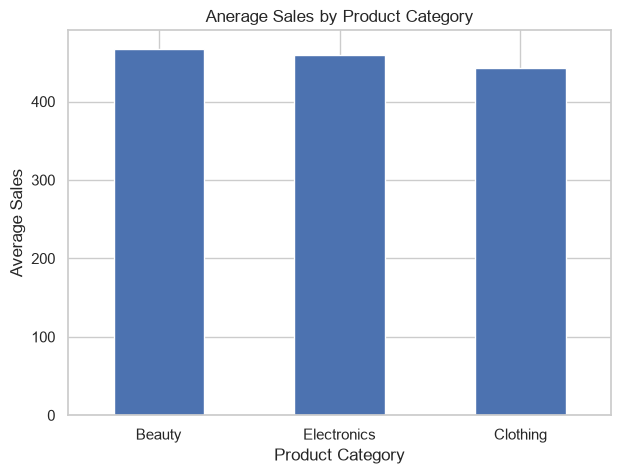

In [75]:
avg_sales.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Anerage Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Sales")

plt.xticks(rotation=0)
plt.show()

### Insight

Beauty products recorded the highest average sales value, followed by Electronics and Clothing.

Although the differences are relatively small, the results suggest that Beauty products generate slightly higher revenue per transaction on average.

## Export Clean Dataset

Save the cleaned dataset for future analysis, dashboard development and business reporting.

In [76]:
df.to_csv(
    "../data/cleaned/retail_sales_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
